# Wykład 1 — iteracja 2  
## Analiza ankiety, plan zajęć i oś pracy z notebookami

Ten notebook ma być **główną osią wykładu** i punktem wejścia do dalszych mini-notebooków.

## Najważniejsza decyzja dydaktyczna

Na tym etapie **nie zaczynamy od bardziej zaawansowanych metod ML**.  
Najpierw skupiamy się na **praktycznym zastosowaniu podstaw**:

- Jupyter / Colab,
- Python jako narzędzie pracy,
- NumPy: `shape`, tablice, indeksowanie, maski,
- pandas: filtrowanie, braki danych, `groupby`, `merge`, `pivot_table`,
- matplotlib: proste wykresy.

Dopiero później, na bazie tej samej ankiety lub zbioru maratońskiego, można wejść w:
- bardziej systematyczne porównywanie rozkładów,
- korelacje i podobieństwa pytań,
- PCA / clustering / prostą analizę ML-ową.

To podejście lepiej pasuje do wyników ankiety: grupa ma już podstawy Python/SQL, ale największa luka jest w **praktycznej analizie danych**.

## Co jest w tym folderze

- `00_analiza_ankiety_i_plan_wykladu.ipynb` — ten notebook,
- `01_jupyter_python_wprawki.ipynb` — krótkie wprawki z Jupytera i czystego Pythona,
- `02_numpy_wprawki.ipynb` — NumPy pod potrzeby ankiety,
- `03_pandas_wprawki.ipynb` — pandas pod potrzeby ankiety,
- `04_matplotlib_wprawki.ipynb` — matplotlib pod potrzeby ankiety,
- zewnetrzne linki do upstreamowych notebookow Jake'a VanderPlasa zamiast lokalnej kopii,
- `data/Ankieta_ML.csv` — dane wejściowe,
- `plots/` i `tables/` — wykresy i tabele generowane przez ten notebook.

## Proponowana oś wykładu

1. **Ręczna analiza ankiety**: co widać „na oko” i jakie mamy hipotezy.
2. **Deskryptywna analiza w pandas**: średnie, rozrzut, kontrasty pytań.
3. **Ćwiczenie narzędziowe**: Jupyter + Python + NumPy + pandas + matplotlib.
4. **Powrót do ankiety**: zastosowanie poznanych narzędzi do własnych danych grupy.
5. **Maratończycy** dopiero w drugiej części lub na kolejnym spotkaniu, jako płynniejszy case do `groupby`, `pivot_table` i wizualizacji.

## Lista notebooków VanderPlasa, które warto włączyć

### IPython / Jupyter
- [01.01 Help and Documentation](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/01.01-Help-And-Documentation.ipynb)
- [01.06 Errors and Debugging](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/01.06-Errors-and-Debugging.ipynb)

### NumPy
- [02.01 Understanding Data Types](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/02.01-Understanding-Data-Types.ipynb)
- [02.02 The Basics of NumPy Arrays](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/02.02-The-Basics-Of-NumPy-Arrays.ipynb)
- [02.04 Computation on arrays: aggregates](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/02.04-Computation-on-arrays-aggregates.ipynb)
- [02.06 Boolean Arrays and Masks](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/02.06-Boolean-Arrays-and-Masks.ipynb)

### pandas
- [03.02 Data Indexing and Selection](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/03.02-Data-Indexing-and-Selection.ipynb)
- [03.04 Missing Values](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/03.04-Missing-Values.ipynb)
- [03.07 Merge and Join](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/03.07-Merge-and-Join.ipynb)
- [03.08 Aggregation and Grouping](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/03.08-Aggregation-and-Grouping.ipynb)
- [03.09 Pivot Tables](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/03.09-Pivot-Tables.ipynb)
- [03.10 Working With Strings](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/03.10-Working-With-Strings.ipynb)

### matplotlib
- [04.01 Simple Line Plots](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/04.01-Simple-Line-Plots.ipynb)
- [04.02 Simple Scatter Plots](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/04.02-Simple-Scatter-Plots.ipynb)
- [04.05 Histograms and Binnings](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/04.05-Histograms-and-Binnings.ipynb)

### Jak to scalać
Najlepszy tryb to nie liniowe „czytanie” całych notebooków, tylko:
1. pokazujesz **wybrany fragment** VanderPlasa,
2. od razu przechodzicie do **lokalnej wprawki** z tego samego tematu,
3. wracacie do **analizy ankiety** i stosujecie narzędzie na realnych danych grupy.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ścieżki lokalne
BASE = Path(".")
DATA_PATH = BASE / "data" / "Ankieta_ML.csv"
PLOTS_DIR = BASE / "plots"
TABLES_DIR = BASE / "tables"

df_raw = pd.read_csv(DATA_PATH)
timestamp_col = df_raw.columns[0]
questions = df_raw.columns[1:].tolist()

df = df_raw.copy()
for c in questions:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# W pytaniach o feedback 0 oznacza "nie było mnie".
# Żeby nie zaniżać średnich, traktujemy 0 jako brak danych.
df_no0 = df.copy()
for c in questions:
    df_no0[c] = df_no0[c].replace(0, np.nan)

print("Liczba odpowiedzi:", len(df_no0))
print("Liczba pytań:", len(questions))


Liczba odpowiedzi: 25
Liczba pytań: 64


In [3]:
section_map = {}
for i in range(1, 65):
    if 1 <= i <= 8:
        sec = "Python / programowanie"
    elif 9 <= i <= 15:
        sec = "NumPy / pandas / wizualizacja"
    elif 16 <= i <= 19:
        sec = "SQL / relacyjne bazy"
    elif 20 <= i <= 31:
        sec = "Matematyka i statystyka"
    elif 32 <= i <= 42:
        sec = "ML podstawy + sprawność algorytmiczna"
    else:
        sec = "Praca, preferencje i feedback"
    section_map[i] = sec

qmap = pd.DataFrame({
    "qnum": range(1, 65),
    "question": questions,
    "section": [section_map[i] for i in range(1, 65)]
})

qmap.head(20)


,qnum,question,section
0,1,Potrafię swobodnie pracować w Jupyterze / Colabie,Python / programowanie
1,2,Rozumiem podstawowe typy danych w Pythonie (li...,Python / programowanie
2,3,Potrafię pociąć string (przez split) do listy.,Python / programowanie
3,4,Potrafię programować obiektowo w pythonie,Python / programowanie
4,5,Potrafię pisać funkcje i używać parametrów / w...,Python / programowanie
5,6,Potrafię samodzielnie debugować prosty błąd,Python / programowanie
6,7,"Potrafię korzystać z dokumentacji biblioteki, ...",Python / programowanie
7,8,Rozumiem różnicę między pętlą a podejściem bar...,Python / programowanie
8,9,Potrafię utworzyć tablicę NumPy i wykonywać na...,NumPy / pandas / wizualizacja
9,10,"Rozumiem kształt danych (shape), indeksowanie ...",NumPy / pandas / wizualizacja


In [4]:
question_stats = pd.DataFrame({
    "qnum": range(1, 65),
    "question": questions,
    "section": [section_map[i] for i in range(1, 65)],
    "mean": [df_no0[c].mean() for c in questions],
    "median": [df_no0[c].median() for c in questions],
    "std": [df_no0[c].std() for c in questions],
    "pct_5": [(df_no0[c] == 5).mean() * 100 for c in questions],
    "pct_4_5": [(df_no0[c] >= 4).mean() * 100 for c in questions],
    "pct_1_2": [(df_no0[c].isin([1, 2])).mean() * 100 for c in questions],
    "n_zero": [(df[c] == 0).sum() for c in questions],
    "n_valid": [df_no0[c].notna().sum() for c in questions]
})

question_stats.sort_values("mean").head(15)


,qnum,question,section,mean,median,std,pct_5,pct_4_5,pct_1_2,n_zero,n_valid
49,50,Preferuję zaliczenie w formie pisemnej,"Praca, preferencje i feedback",1.60,1.0,1.040833,4.0,8.0,88.0,0,25
58,59,Potrzebuję ścieżki wyrównawczej / dodatkowych ...,"Praca, preferencje i feedback",1.92,2.0,0.996661,0.0,8.0,72.0,0,25
61,62,Stresuje mnie matematyka / statystyka w kontek...,"Praca, preferencje i feedback",2.08,2.0,0.953939,0.0,8.0,68.0,0,25
63,64,Wolę pracować w parze lub małej grupie,"Praca, preferencje i feedback",2.52,2.0,1.388044,12.0,24.0,52.0,0,25
36,37,"Rozumiem, czym jest data leakage",ML podstawy + sprawność algorytmiczna,2.52,3.0,1.194432,8.0,16.0,48.0,0,25
12,13,Potrafię łączyć tabele / ramki danych (merge /...,NumPy / pandas / wizualizacja,2.52,2.0,1.294862,12.0,20.0,56.0,0,25
11,12,Potrafię użyć groupby / agregacji w pandas,NumPy / pandas / wizualizacja,2.56,2.0,1.293574,8.0,28.0,56.0,0,25
60,61,Chciał(a)bym regularnych krótkich konsultacji ...,"Praca, preferencje i feedback",2.64,3.0,0.810350,0.0,8.0,32.0,0,25
13,14,Potrafię wykrywać i obsługiwać braki danych,NumPy / pandas / wizualizacja,2.68,3.0,1.314027,8.0,32.0,48.0,0,25
59,60,Był(a)bym zainteresowany(a) ścieżką advanced /...,"Praca, preferencje i feedback",2.88,3.0,1.301281,16.0,28.0,40.0,0,25


In [5]:
domain_defs = {
    "Python / programowanie": list(range(1, 9)),
    "NumPy / pandas / wizualizacja": list(range(9, 16)),
    "SQL / relacyjne bazy": list(range(16, 20)),
    "Matematyka i statystyka": list(range(20, 32)),
    "ML podstawy + sprawność algorytmiczna": list(range(32, 43)),
    "Praca, preferencje i feedback": list(range(43, 65)),
}

domain_rows = []
for name, idxs in domain_defs.items():
    cols = [questions[i - 1] for i in idxs]
    student_means = df_no0[cols].mean(axis=1)
    domain_rows.append({
        "domain": name,
        "mean": student_means.mean(),
        "median": student_means.median(),
        "std_between_students": student_means.std(),
        "n_questions": len(cols)
    })

domain_summary = pd.DataFrame(domain_rows).sort_values("mean")
domain_summary


,domain,mean,median,std_between_students,n_questions
1,NumPy / pandas / wizualizacja,2.937143,3.000000,1.200255,7
4,ML podstawy + sprawność algorytmiczna,3.269091,3.272727,1.045283,11
5,"Praca, preferencje i feedback",3.569495,3.681818,0.255123,22
3,Matematyka i statystyka,3.926667,4.166667,0.747805,12
0,Python / programowanie,3.930000,4.000000,0.762124,8
2,SQL / relacyjne bazy,4.390000,4.500000,0.591080,4


## Wykres 1. Średnie domenowe

Kod poniżej generuje wykres zapisany także do `plots/01_domain_summary.png`.


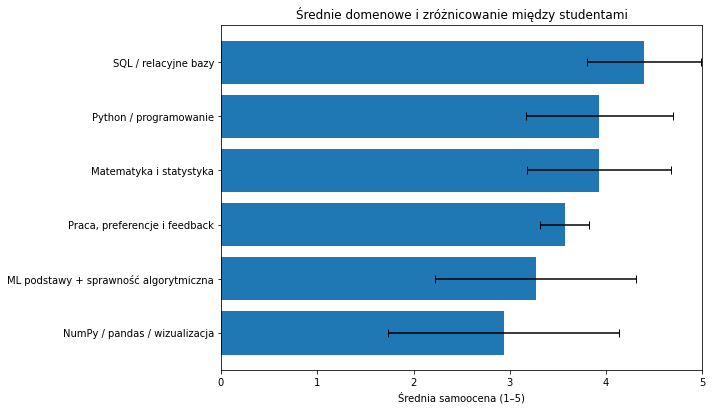

In [6]:
plt.figure(figsize=(10, 5.8))
plt.barh(
    domain_summary["domain"],
    domain_summary["mean"],
    xerr=domain_summary["std_between_students"],
    capsize=4
)
plt.xlim(0, 5)
plt.xlabel("Średnia samoocena (1–5)")
plt.title("Średnie domenowe i zróżnicowanie między studentami")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_domain_summary.png", dpi=180)
plt.show()


## Szybkie podsumowanie tego, co już widać

### Najmocniejsze domeny
- SQL / relacyjne bazy,
- ogólny Python,
- matematyka i statystyka na poziomie podstawowym,
- organizacja pracy i czytanie dokumentacji.

### Najsłabsza domena
- NumPy / pandas / wizualizacja.

### Najbardziej praktyczny wniosek
To nie jest grupa, której trzeba robić pełny kurs „Python od zera”.  
To jest grupa, której trzeba pomóc **przejść od składni do pracy na danych**.


## Wykres 2. Pytania o największym rozrzucie

Ten wykres pomaga zauważyć, gdzie grupa jest najbardziej nierówna.


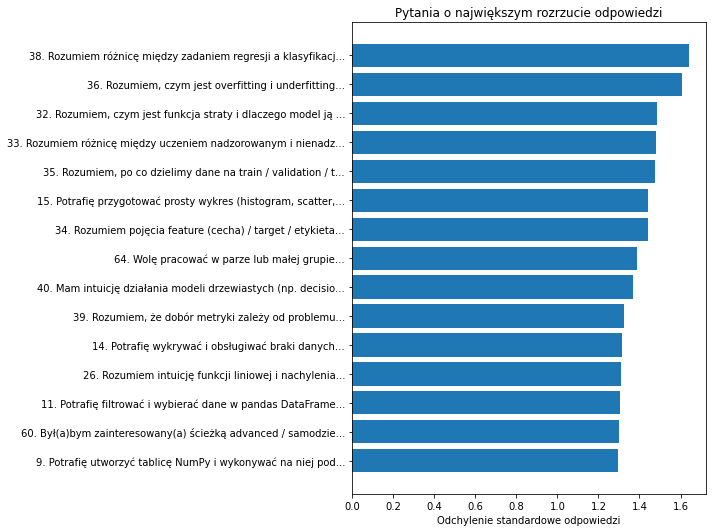

In [7]:
top_disp = question_stats.sort_values("std", ascending=False).head(15).copy()
top_disp["label"] = (
    top_disp["qnum"].astype(str)
    + ". "
    + top_disp["question"].str.slice(0, 55)
    + "..."
)

plt.figure(figsize=(10, 7.5))
plt.barh(top_disp["label"][::-1], top_disp["std"][::-1])
plt.xlabel("Odchylenie standardowe odpowiedzi")
plt.title("Pytania o największym rozrzucie odpowiedzi")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_top_dispersion.png", dpi=180)
plt.show()


## Co mówi rozrzut odpowiedzi

Wysoki rozrzut jest tu równie ważny jak sama średnia.  
Pytania o największym rozrzucie to niekoniecznie „najsłabsze” pytania, tylko pytania, na których grupa jest **najbardziej nierówna**.

To szczególnie ważne dla:
- części pojęć ML,
- prostych wykresów,
- filtrowania / `shape`,
- Jupytera,
- preferencji pracy (indywidualnie vs w grupie).

**Wniosek dydaktyczny:**  
warto przygotować zadania na 2–3 poziomach:
- poziom podstawowy,
- poziom standardowy,
- poziom rozszerzony.


## Wykres 3. Kluczowe kontrasty

Poniższy kod porównuje pary pytań, które warto omówić wspólnie na wykładzie.


In [8]:
pairs = [
    (12, "pandas groupby", 17, "SQL GROUP BY"),
    (13, "pandas merge", 18, "SQL JOIN"),
    (15, "prosty wykres", 53, "chęć więcej praktyki"),
    (19, "klucze / granularność", 18, "JOIN praktyczny"),
    (20, "średnia/mediana/odch", 21, "percentyl/kwartyl/rozkład"),
    (22, "korelacja", 23, "kowariancja"),
    (26, "nachylenie funkcji", 29, "liczenie pochodnych"),
    (29, "liczenie pochodnych", 30, "pochodna jako zmiana"),
    (27, "liniowa vs kwadratowa", 28, "wielomiany wyższych stopni"),
    (35, "train/val/test", 36, "overfitting"),
    (36, "overfitting", 37, "data leakage"),
    (38, "regresja vs klasyfikacja", 39, "dobór metryki"),
    (48, "realne nauczenie się", 49, "sprawne zaliczenie"),
    (50, "zaliczenie pisemne", 51, "zaliczenie projektowe"),
    (52, "więcej teorii", 53, "więcej praktyki"),
    (54, "forma zajęć wczoraj", 56, "forma zajęć dziś"),
    (55, "zrozumienie wczoraj", 57, "zrozumienie dziś"),
    (63, "praca indywidualna", 64, "praca w parze / grupie"),
]

pair_rows = []
for a, alabel, b, blabel in pairs:
    qa = questions[a - 1]
    qb = questions[b - 1]
    va = df_no0[qa]
    vb = df_no0[qb]
    common = ~(va.isna() | vb.isna())
    diff = va[common] - vb[common]
    pair_rows.append({
        "qa_num": a,
        "qa_label": alabel,
        "qb_num": b,
        "qb_label": blabel,
        "mean_a": va[common].mean(),
        "mean_b": vb[common].mean(),
        "mean_diff_a_minus_b": diff.mean(),
        "median_diff_a_minus_b": diff.median(),
        "pct_a_gt_b": (diff > 0).mean() * 100,
        "pct_a_lt_b": (diff < 0).mean() * 100,
    })

pairwise_contrasts = pd.DataFrame(pair_rows)
pairwise_contrasts


,qa_num,qa_label,qb_num,qb_label,mean_a,mean_b,mean_diff_a_minus_b,median_diff_a_minus_b,pct_a_gt_b,pct_a_lt_b
0,12,pandas groupby,17,SQL GROUP BY,2.560000,4.520000,-1.960000,-2.0,0.000000,88.000000
1,13,pandas merge,18,SQL JOIN,2.520000,4.240000,-1.720000,-2.0,0.000000,80.000000
2,15,prosty wykres,53,chęć więcej praktyki,3.400000,3.960000,-0.560000,-1.0,32.000000,52.000000
3,19,klucze / granularność,18,JOIN praktyczny,4.200000,4.240000,-0.040000,0.0,12.000000,12.000000
4,20,średnia/mediana/odch,21,percentyl/kwartyl/rozkład,4.360000,3.760000,0.600000,0.0,48.000000,4.000000
5,22,korelacja,23,kowariancja,3.960000,2.960000,1.000000,1.0,72.000000,4.000000
6,26,nachylenie funkcji,29,liczenie pochodnych,3.720000,4.440000,-0.720000,0.0,8.000000,48.000000
7,29,liczenie pochodnych,30,pochodna jako zmiana,4.440000,4.080000,0.360000,0.0,36.000000,4.000000
8,27,liniowa vs kwadratowa,28,wielomiany wyższych stopni,4.520000,4.360000,0.160000,0.0,12.000000,0.000000
9,35,train/val/test,36,overfitting,3.520000,3.440000,0.080000,0.0,16.000000,16.000000


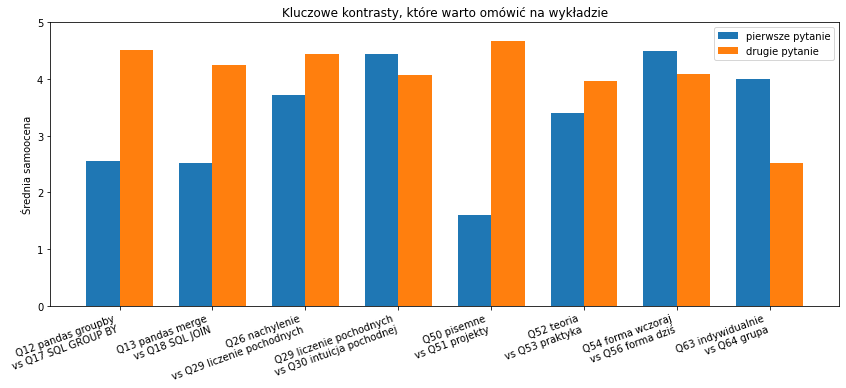

In [9]:
contrast_labels = [
    "Q12 pandas groupby\nvs Q17 SQL GROUP BY",
    "Q13 pandas merge\nvs Q18 SQL JOIN",
    "Q26 nachylenie\nvs Q29 liczenie pochodnych",
    "Q29 liczenie pochodnych\nvs Q30 intuicja pochodnej",
    "Q50 pisemne\nvs Q51 projekty",
    "Q52 teoria\nvs Q53 praktyka",
    "Q54 forma wczoraj\nvs Q56 forma dziś",
    "Q63 indywidualnie\nvs Q64 grupa",
]
contrast_pairs = [(12, 17), (13, 18), (26, 29), (29, 30), (50, 51), (52, 53), (54, 56), (63, 64)]

vals = []
for a, b in contrast_pairs:
    vals.append((a, b, df_no0[questions[a - 1]].mean(), df_no0[questions[b - 1]].mean()))

x = np.arange(len(vals))
width = 0.36

plt.figure(figsize=(12, 5.5))
plt.bar(x - width / 2, [v[2] for v in vals], width, label="pierwsze pytanie")
plt.bar(x + width / 2, [v[3] for v in vals], width, label="drugie pytanie")
plt.xticks(x, contrast_labels, rotation=20, ha="right")
plt.ylim(0, 5)
plt.ylabel("Średnia samoocena")
plt.title("Kluczowe kontrasty, które warto omówić na wykładzie")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_key_contrasts.png", dpi=180)
plt.show()


## Dlaczego kontrasty są ważniejsze niż pojedyncze średnie

To właśnie kontrasty pokazują najciekawsze rzeczy:
- studenci deklarują znajomość SQL, ale znacznie słabiej czują pandas `groupby` i `merge`,
- potrafią liczyć proste pochodne lepiej niż rozumieją pochodną jako zmianę,
- projekty bardzo wyraźnie wygrywają z zaliczeniem pisemnym,
- praktyka wygrywa z teorią,
- wczorajsza forma zajęć była oceniona wyżej niż dzisiejsza, ale różnica w zrozumieniu jest mniejsza.

To są dokładnie te miejsca, gdzie analiza „na oko” dobrze łączy się z prostą analizą danych.


## Wykres 4. Rozkłady odpowiedzi dla feedbacku po dwóch pierwszych spotkaniach


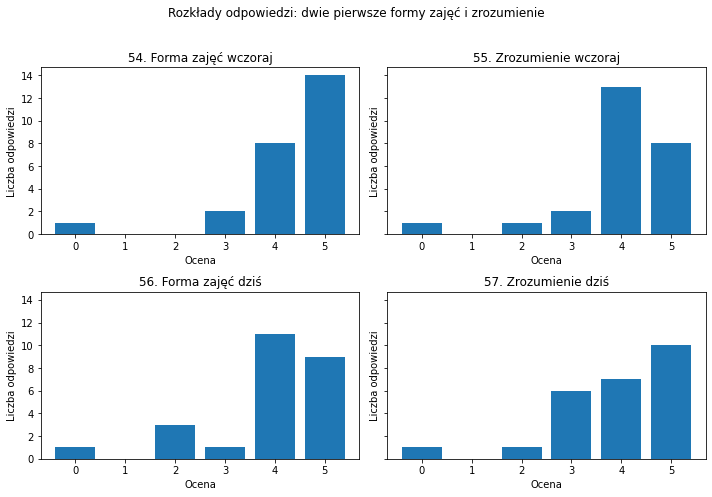

In [10]:
feedback_qs = [54, 55, 56, 57]
feedback_labels = [
    "54. Forma zajęć wczoraj",
    "55. Zrozumienie wczoraj",
    "56. Forma zajęć dziś",
    "57. Zrozumienie dziś",
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
for ax, qnum, label in zip(axes.flat, feedback_qs, feedback_labels):
    s = df[questions[qnum - 1]].value_counts().sort_index()
    idx = [0, 1, 2, 3, 4, 5]
    vals = [s.get(i, 0) for i in idx]
    ax.bar(idx, vals)
    ax.set_title(label)
    ax.set_xticks(idx)
    ax.set_xlabel("Ocena")
    ax.set_ylabel("Liczba odpowiedzi")

plt.suptitle("Rozkłady odpowiedzi: dwie pierwsze formy zajęć i zrozumienie")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(PLOTS_DIR / "04_feedback_counts.png", dpi=180)
plt.show()


## Co można powiedzieć o dwóch pierwszych spotkaniach

Najciekawsze są dwie obserwacje:
1. **forma wczoraj** ma więcej ocen 5 niż **forma dziś**,
2. ale **zrozumienie** nie spada równie mocno jak sam odbiór formy.

Interpretacja robocza:
- forma hands-on mogła być trochę mniej komfortowa,
- ale nie była wyraźnie mniej skuteczna.

To dobry argument za tym, żeby utrzymać wykład z małymi blokami samodzielnej pracy, tylko lepiej dozować trudność.


## Helper: szybkie porównywanie rozkładów wybranych pytań


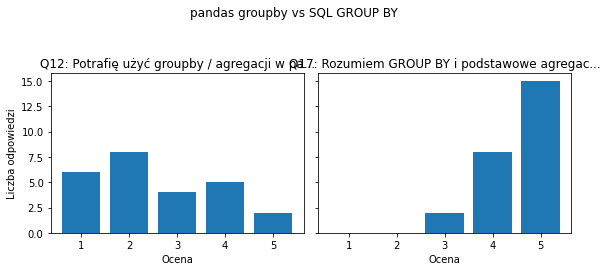

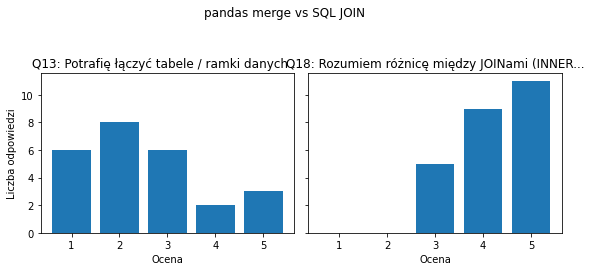

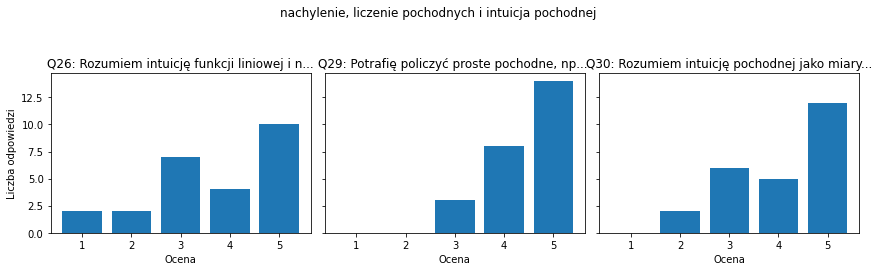

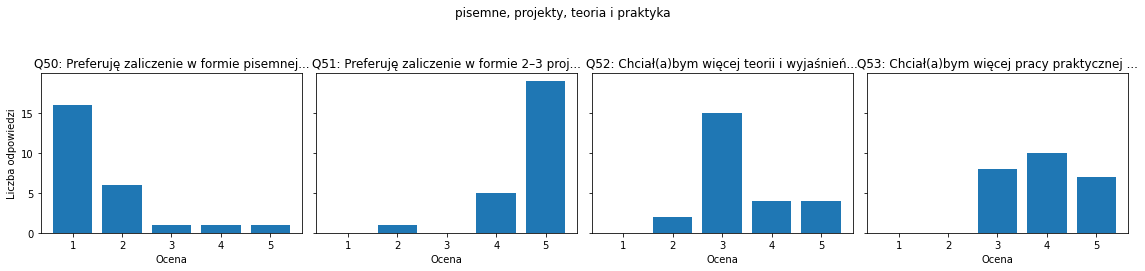

In [11]:
def plot_question_distributions(qnums, title=None):
    fig, axes = plt.subplots(1, len(qnums), figsize=(4 * len(qnums), 3.8), sharey=True)
    if len(qnums) == 1:
        axes = [axes]
    for ax, q in zip(axes, qnums):
        s = df[questions[q - 1]].replace(0, np.nan).value_counts().sort_index()
        xs = [1, 2, 3, 4, 5]
        ax.bar(xs, [s.get(i, 0) for i in xs])
        ax.set_title(f"Q{q}: " + questions[q - 1][:38] + "...")
        ax.set_xticks(xs)
        ax.set_xlabel("Ocena")
    axes[0].set_ylabel("Liczba odpowiedzi")
    if title:
        plt.suptitle(title)
        plt.tight_layout(rect=[0, 0, 1, 0.92])
    else:
        plt.tight_layout()
    plt.show()

# Przykładowe porównania do uruchamiania na wykładzie:
plot_question_distributions([12, 17], "pandas groupby vs SQL GROUP BY")
plot_question_distributions([13, 18], "pandas merge vs SQL JOIN")
plot_question_distributions([26, 29, 30], "nachylenie, liczenie pochodnych i intuicja pochodnej")
plot_question_distributions([50, 51, 52, 53], "pisemne, projekty, teoria i praktyka")


## Ręczna analiza ankiety — wersja dopracowana

Ta część przepisuje i porządkuje ręczne uwagi do ankiety.  
Założenie jest takie:

- najpierw patrzymy na **poziom średni**,
- potem na **rozrzut odpowiedzi**,
- potem na **kontrasty pytań pokrewnych**,
- a na końcu zamieniamy to w **decyzje dydaktyczne**.

To znaczy: sama średnia nie wystarczy.  
Pytanie może mieć średnią „średnią”, ale bardzo duży rozrzut, a to oznacza, że grupa jest **nierówna** i trzeba przygotować zadania warstwowe.

### Jak czytać tę ankietę
- **średnia wysoka + mały rozrzut**: temat raczej bezpieczny, wystarczy krótkie przypomnienie,
- **średnia wysoka + duży rozrzut**: część grupy umie, część nie, warto dać warianty zadań,
- **średnia niska + mały rozrzut**: temat ogólnie słaby, trzeba go ćwiczyć od podstaw,
- **średnia niska + duży rozrzut**: temat jest słaby i nierówny, trzeba ćwiczyć + dać ścieżkę support i opcję advanced.

---

## 1. Python / programowanie (Q1–Q8)

**Q1. Jupyter / Colab**  
Wynik jest niższy niż w zwykłych podstawach Pythona i ma duży rozrzut. To jest sygnał, że warto zacząć od krótkiego wspólnego wejścia do środowiska.  
**Wniosek dydaktyczny:** zrobić prosty wspólny start w Colabie lub lokalnym Jupyterze. Nie polecam jednego wspólnego użytkownika na jednej maszynie, bo to zbyt łatwo wysypać.

**Q2. Typy danych w Pythonie**  
To wygląda dobrze.  
**Wniosek:** nie robić z tego dużego wykładu, tylko krótką rozgrzewkę.

**Q3. Stringi / `split`**  
Też wygląda dobrze.  
**Wniosek:** dobra rzecz na szybkie wejście i oswojenie notebooka.

**Q4. OOP**  
Średnio jest nieźle, ale rozrzut jest zauważalny.  
**Wniosek:** krótka wprawka z klasami ma sens, ale nie jako główna oś dnia.

**Q5. Funkcje**  
Wysoko i dość stabilnie.  
**Wniosek:** przypomnieć tylko przy okazji ćwiczeń.

**Q6. Debugowanie**  
Dość dobrze, ale nie idealnie.  
**Wniosek:** 5 minut na czytanie błędów i proste debugowanie bardzo się opłaci.

**Q7. Korzystanie z dokumentacji**  
Bardzo dobry sygnał.  
**Wniosek:** można bez stresu odsyłać studentów do helpa i dokumentacji.

**Q8. Różnica między pętlą a podejściem wektorowym / kolekcjami**  
Tu widać większą niepewność niż w czystych podstawach Pythona.  
**Wniosek:** koniecznie pokazać bardzo prosty kontrast:
- pętla po liście,
- to samo przez tablicę NumPy / maskę / agregację.

---

## 2. NumPy / pandas / wizualizacja (Q9–Q15)

To jest najsłabszy blok całej ankiety i najważniejszy praktycznie.

**Q9. Podstawowe operacje na tablicy NumPy**  
Nie jest tragicznie, ale dużo słabiej niż podstawy Pythona.  
**Wniosek:** NumPy trzeba robić od podstaw, ale krótko i konkretnie.

**Q10. `shape`, indeksowanie i slicing w NumPy**  
To jest jeden z pierwszych bardzo wyraźnie słabych punktów.  
**Wniosek:** obowiązkowo ćwiczenia z wymiarowości danych, `shape`, 1D vs 2D, slicing i maskami.

**Q11. Filtrowanie i wybieranie danych w pandas**  
Widać wyraźny zjazd względem Pythona.  
**Wniosek:** filtrowanie w DataFrame musi być jednym z głównych ćwiczeń.

**Q12. `groupby` w pandas**  
To jest bardzo słaby punkt.  
**Wniosek:** potraktować `groupby` jako jeden z filarów tego wykładu.

**Q13. `merge` / `join` w pandas**  
Jeszcze słabiej niż `groupby`.  
**Wniosek:** bardzo mocno ćwiczyć `merge` i łączyć to z przypomnieniem kluczy / granularności.

**Q14. Braki danych**  
Raczej równomiernie słabo.  
**Wniosek:** studenci mogą nie mieć automatyzmu w `NaN`, `isna`, `fillna`, `dropna`; trzeba to przećwiczyć.

**Q15. Prosty wykres**  
To nie jest pełna katastrofa, ale rozrzut jest bardzo duży. Część studentów umie, część nie.  
**Wniosek:** nie zakładać, że „wszyscy umieją zrobić wykres”, tylko pokazać 3–4 najprostsze przypadki od zera.

**Najmocniejszy wniosek z bloku Q9–Q15**  
To nie jest problem „Python od zera”. To jest problem **przejścia do analizy danych**.  
Właśnie dlatego ten wykład powinien być oparty na:
`shape -> filtrowanie -> braki danych -> groupby -> merge -> wykres`.

---

## 3. SQL / relacyjne bazy (Q16–Q19)

**Q16. SELECT / WHERE / ORDER BY**  
Bardzo wysoko.

**Q17. SQL GROUP BY**  
Bardzo wysoko.

**Q18. SQL JOIN**  
Wysoko.

**Q19. Klucze, klucze obce i granularność**  
Trochę niżej niż czysty SQL operacyjny.

**Wniosek zbiorczy:**  
Studenci deklarują znajomość SQL, ale możliwe, że bardziej „operacyjnie” niż modelowo.  
Najlepszy ruch dydaktyczny to nie robić wielkiej powtórki z SQL, tylko użyć SQL jako pomostu do pandas:

- `SELECT` -> wybór kolumn,
- `WHERE` -> maska,
- `GROUP BY` -> `groupby`,
- `JOIN` -> `merge`,
- klucz / granularność -> warunki poprawnego łączenia tabel.

To jest jeden z najcenniejszych kontrastów całej ankiety:  
**Q12 vs Q17** i **Q13 vs Q18**.

---

## 4. Matematyka i statystyka (Q20–Q31)

Tutaj wynik jest bardziej zniuansowany niż „umieją / nie umieją”.

**Q20. Średnia, mediana, odchylenie, wariancja**  
Wysoko. To jest bezpieczny obszar.

**Q21. Percentyl / kwartyl / rozkład**  
Wyraźnie gorzej niż Q20.  
**Wniosek:** trzeba przypomnieć rozkład i kwantyle, najlepiej wizualnie.

**Q22. Korelacja i brak przyczynowości**  
Dość wysoko.

**Q23. Kowariancja**  
Wyraźnie słabiej niż korelacja.  
**Wniosek:** można to pokazać krótko jako kontrast pojęciowy, ale nie robić z tego długiego bloku.

**Q24. Prawdopodobieństwo warunkowe**  
Średnio.  
**Wniosek:** raczej krótka intuicja niż formalny rachunek.

**Q25. Próbkowanie i błąd estymacji**  
Niżej i mniej pewnie.  
**Wniosek:** temat warto pokazać intuicyjnie na przykładzie, nie przez definicje.

**Q26. Intuicja funkcji liniowej i nachylenia**  
Nieźle, ale słabiej niż „policzyć pochodną”.  
**Wniosek:** Twoja intuicja jest dobra — część studentów prawdopodobnie umie liczyć ze wzorów, ale słabiej rozumie geometrię.

**Q27. Różnica między funkcją liniową a kwadratową**  
Bardzo dobrze.

**Q28. Różnica między liniową / kwadratową a wielomianami wyższych stopni**  
Też dobrze.

**Q29. Liczenie prostych pochodnych**  
Bardzo wysoko.

**Q30. Pochodna jako miara zmiany**  
Niżej niż Q29.  
**Wniosek:** bardzo dobry materiał do GeoGebry: liczenie jest, intuicja geometryczna jest słabsza.

**Q31. Wektory i macierze**  
Dość dobrze, ale nie perfekcyjnie.  
**Wniosek:** warto dać 5–10 minut wizualnego przypomnienia.

**Najmocniejszy wniosek z matematyki/statystyki**  
Nie widać tu katastrofy, ale widać różnicę między:
- **rachunkiem / rozpoznaniem wzoru**, a
- **intuicją geometryczną i statystyczną**.

To bardzo dobrze pasuje do Twojego pomysłu na krótkie wprawki w GeoGebrze.

---

## 5. ML podstawy + sprawność algorytmiczna (Q32–Q42)

Tu widać dokładnie to, czego można było się spodziewać:  
grupa **coś kojarzy**, ale rozkłady są nierówne i część pojęć jest naprawdę słaba.

**Q32. Funkcja straty**  
Słabo i z dużym rozrzutem.  
**Wniosek:** trzeba wytłumaczyć od zera, intuicyjnie.

**Q33. Nadzorowane / nienadzorowane**  
Średnio, z dużym rozrzutem.  
**Wniosek:** część studentów zna, część nie — nadaje się na pierwszy prosty kontrast.

**Q34. Feature / target / etykieta**  
Słabiej niż można by chcieć.  
**Wniosek:** po wyjaśnieniu powinno pójść szybko, ale nie wolno zakładać, że to oczywiste.

**Q35. Train / validation / test**  
Średnio.

**Q36. Overfitting / underfitting**  
Średnio, ale z bardzo dużym rozrzutem.  
**Wniosek:** jest grupa, która to zna, i grupa, która prawie nie zna.

**Q37. Data leakage**  
Jeden z najgorszych wyników w całej części ML.  
**Wniosek:** koniecznie wytłumaczyć na przykładzie.

**Q38. Regresja vs klasyfikacja**  
Rozrzut bardzo duży.  
**Wniosek:** temat trzeba wyłożyć prosto i wizualnie.

**Q39. Dobór metryki zależy od problemu**  
Średnio, ale tu część studentów może zgadywać intuicyjnie.

**Q40. Intuicja modeli drzewiastych**  
Raczej słabo i nierówno.  
**Wniosek:** to będzie temat dopiero później.

**Q41. BFS / DFS**  
Średnio.  
**Wniosek:** nie robiłbym z tego teraz dużego tematu; jeśli wróci, to jako krótki bonus lub support.

**Q42. merge-/quicksort**  
Dość dobrze, ale to nie jest teraz krytyczna oś wykładu.

**Najmocniejszy wniosek z ML**  
Na tym etapie nie ma sensu zaczynać od „bardziej zaawansowanej analizy ML ankiety”.  
Najpierw trzeba zbudować warsztat danych i dopiero potem wrócić do PCA / clusteringu / szerszej eksploracji.

---

## 6. Praca, preferencje i feedback po pierwszych zajęciach (Q43–Q64)

**Q43. Praca z niedookreślonym problemem**  
Dość dobrze, ale bez przesadnej pewności.

**Q44. Planowanie pracy na kilka dni / tygodni**  
Wysoko.

**Q45. Czytanie dokumentacji angielskiej**  
Bardzo wysoko. To świetny sygnał.

**Q46. Prezentowanie wyniku swojej pracy**  
Nieźle, ale z rozrzutem.

**Q47. Współpraca z innymi**  
Wysoko.

**Q48 vs Q49. Nauka materiału vs sprawne zaliczenie**  
Oba wyniki są wysokie. To nie jest sprzeczność; oznacza raczej, że grupa chce się nauczyć, ale też nie chce utrudnionej organizacji kursu.

**Q50 vs Q51. Pisemne vs projekty**  
To jest bardzo mocny i łatwy do pokazania kontrast: projekty zdecydowanie wygrywają z formą pisemną.

**Q52 vs Q53. Więcej teorii vs więcej praktyki**  
Praktyka wygrywa.

**Q54 vs Q56. Forma wczoraj vs forma dziś**  
Wczorajsza forma została oceniona wyżej.

**Q55 vs Q57. Zrozumienie wczoraj vs zrozumienie dziś**  
Różnica jest mniejsza niż w samym „podobało się / nie podobało się”.  
**Wniosek:** dzisiejsza forma mogła być trochę mniej komfortowa, ale niekoniecznie mniej skuteczna.

**Q58. Slajdy vs aktywny udział**  
Nie widać mocnego poparcia dla czysto slajdowego formatu.  
**Wniosek:** warto utrzymać wykład z małymi przerwami na działanie.

**Q59. Ścieżka wyrównawcza**  
Studenci deklaratywnie raczej jej nie chcą.  
**Ale:** wyniki z pandas/NumPy sugerują, że zadania support i tak są potrzebne. Lepiej więc nie nazywać tego „ścieżką wyrównawczą”, tylko po prostu dać poziom podstawowy / standard / rozszerzenie.

**Q60. Ścieżka advanced**  
Jest pewna grupa zainteresowanych, ale nie większość.

**Q61. Regularne checkpointy / konsultacje**  
Raczej umiarkowane zainteresowanie.

**Q62. Stres matematyką / statystyką**  
Raczej niski.

**Q63 vs Q64. Indywidualnie vs w parze / grupie**  
Silniejsza jest preferencja pracy indywidualnej.  
**Wniosek:** główny tryb zajęć może być indywidualny, a opcjonalny projekt grupowy najlepiej zostawić na koniec lub dla chętnych.

---

## 7. Najważniejsze kontrasty, które warto pokazać studentom na wykładzie

Jeśli chcesz zrobić analizę „z ręki”, a potem uzasadnić ją prostymi statystykami i wykresami, to najciekawsze są te pary:

1. **Q12 vs Q17** — pandas `groupby` kontra SQL `GROUP BY`  
2. **Q13 vs Q18** — pandas `merge` kontra SQL `JOIN`  
3. **Q26 vs Q29 vs Q30** — nachylenie funkcji, liczenie pochodnych, intuicja pochodnej  
4. **Q20 vs Q21** — statystyki opisowe kontra kwartyle / rozkład  
5. **Q22 vs Q23** — korelacja kontra kowariancja  
6. **Q50 vs Q51** — pisemne kontra projekty  
7. **Q52 vs Q53** — teoria kontra praktyka  
8. **Q54 vs Q56** — odbiór dwóch form zajęć  
9. **Q55 vs Q57** — zrozumienie dwóch form zajęć  
10. **Q63 vs Q64** — praca indywidualna kontra praca w parze / grupie  

To są miejsca, w których sama średnia nie wystarcza — warto porównywać także **rozklady odpowiedzi**.

---

## 8. Decyzje dydaktyczne wynikające z ankiety

### Co ćwiczyć na pewno
- Jupyter / Colab,
- `shape`, indeksowanie i slicing w NumPy,
- filtrowanie w pandas,
- `groupby`,
- `merge`,
- braki danych,
- prosty matplotlib,
- różnica między liczeniem pochodnej a intuicją pochodnej.

### Co tylko krótko przypomnieć
- typy danych,
- stringi,
- funkcje,
- dokumentacja,
- SQL operacyjny.

### Co zostawić na później
- głębsze wchodzenie w BFS/DFS,
- sortowania,
- drzewa decyzyjne jako model,
- bardziej zaawansowane metody ML,
- pełny blok gier w pygame.

### Co można zostawić jako lekki przerywnik
- krótka wprawka OOP z klasą i metodami,
- ewentualnie bardzo prosty bonus obiektowy / growy, ale tylko jeśli zostanie czas.


## Plan zajęć — iteracja 2

Poniżej wersja planu, która scala:
- analizę ankiety,
- wybrane notebooki VanderPlasa,
- lokalne mini-wprawki,
- Twoje luźne propozycje z wcześniejszych notatek.

### Rdzeń decyzji
Na tym spotkaniu **stawiamy na praktyczne użycie podstaw**.  
Zaawansowaną analizę ML-ową ankiety zostawiamy jako końcówkę albo osobny kolejny krok.

---

### Blok A. Otwarcie i cel wykładu (10–15 min)
- po co analizujemy ankietę,
- jak czytać rozkład odpowiedzi,
- czym różni się średnia od rozrzutu,
- jakie pytania chcemy sobie zadać o tej grupie.

---

### Blok B. Ankieta — analiza ręczna i deskryptywna (60–90 min)
1. najpierw komentarz „na oko”,
2. potem proste statystyki w pandas,
3. potem kontrasty pytań pokrewnych.

**Cel dydaktyczny:**  
pokazać, że analiza danych zaczyna się od hipotez, a dopiero potem wchodzą narzędzia.

**Najważniejsze kontrasty do pokazania:**
- pandas `groupby` vs SQL `GROUP BY`,
- pandas `merge` vs SQL `JOIN`,
- liczenie pochodnych vs intuicja pochodnej,
- projekty vs zaliczenie pisemne,
- teoria vs praktyka,
- forma zajęć wczoraj vs dziś.

---

### Blok C. Wybrane cegły z VanderPlasa + lokalne wprawki (około 2.5–3 h łącznie)

#### C1. Jupyter / IPython (20–30 min)
Najpierw krótko:
- [01.01 Help and Documentation](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/01.01-Help-And-Documentation.ipynb)
- [01.06 Errors and Debugging](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/01.06-Errors-and-Debugging.ipynb)

Potem lokalnie:
- [01_jupyter_python_wprawki.ipynb](01_jupyter_python_wprawki.ipynb)

**Po co:**  
bo Jupyter ma niższy wynik i większy rozrzut niż zwykłe podstawy Pythona.

#### C2. NumPy (35–45 min)
Najpierw krótko:
- [02.01 Understanding Data Types](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/02.01-Understanding-Data-Types.ipynb)
- [02.02 The Basics of NumPy Arrays](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/02.02-The-Basics-Of-NumPy-Arrays.ipynb)
- [02.04 Computation on arrays: aggregates](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/02.04-Computation-on-arrays-aggregates.ipynb)
- [02.06 Boolean Arrays and Masks](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/02.06-Boolean-Arrays-and-Masks.ipynb)

Potem lokalnie:
- [02_numpy_wprawki.ipynb](02_numpy_wprawki.ipynb)

**Po co:**  
bo `shape`, slicing, maski i wektorowość są jednym z głównych braków.

#### C3. pandas (60–75 min)
Najpierw krótko:
- [03.02 Data Indexing and Selection](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/03.02-Data-Indexing-and-Selection.ipynb)
- [03.04 Missing Values](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/03.04-Missing-Values.ipynb)
- [03.07 Merge and Join](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/03.07-Merge-and-Join.ipynb)
- [03.08 Aggregation and Grouping](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/03.08-Aggregation-and-Grouping.ipynb)
- [03.09 Pivot Tables](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/03.09-Pivot-Tables.ipynb)
- [03.10 Working With Strings](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/03.10-Working-With-Strings.ipynb)

Potem lokalnie:
- [03_pandas_wprawki.ipynb](03_pandas_wprawki.ipynb)

**Po co:**  
to jest najważniejszy blok całego spotkania.

#### C4. matplotlib (25–35 min)
Najpierw krótko:
- [04.01 Simple Line Plots](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/04.01-Simple-Line-Plots.ipynb)
- [04.02 Simple Scatter Plots](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/04.02-Simple-Scatter-Plots.ipynb)
- [04.05 Histograms and Binnings](https://github.com/jakevdp/PythonDataScienceHandbook/blob/master/notebooks_v1/04.05-Histograms-and-Binnings.ipynb)

Potem lokalnie:
- [04_matplotlib_wprawki.ipynb](04_matplotlib_wprawki.ipynb)

**Po co:**  
bo wykresy trzeba przećwiczyć od zera, a nie zakładać, że wszyscy je umieją.

---

### Blok D. Powrót do ankiety (30–45 min)
Po poznaniu narzędzi wracacie do ankiety i próbujecie:
- policzyć średnie,
- zrobić `groupby` po blokach,
- porównać pokrewne pytania,
- narysować 1–2 wykresy.

To dobrze domyka zajęcia: narzędzie -> wprawka -> zastosowanie na własnych danych.

---

### Blok E. GeoGebra i intuicja matematyczna (krótkie wstawki, nie osobny długi blok)
Najlepiej jako 5–10 minutowe przerywniki przy temacie:
- nachylenie i funkcja liniowa,
- pochodna jako zmiana,
- overfit / underfit,
- PCA jako obrót układu,
- gradient descent.

---

### Blok F. Co zostawić jako opcję / bonus
- Pygame / prosta gra 2D,
- większy blok OOP,
- bardziej zaawansowane metody ML na ankiecie.

To może być bardzo dobry przerywnik lub ciekawostka, ale **nie powinno zjeść osi wykładu**.

---

## Krótka rekomendacja końcowa

Jeśli trzeba coś uciąć, to:
1. **nie ucinaj** ankiety,
2. **nie ucinaj** pandas `groupby` / `merge`,
3. **nie ucinaj** prostych wykresów,
4. **ucinaj najpierw** bonusy typu gry / większy blok OOP / bardziej zaawansowane ML.
